# C09 – Model Comparison, Final Test and Saving the Classifier
**IT3051 Fundamentals of Data Mining – Mini Project 2026 – PE2 (modelling)**
**Task:** Classification – predict **`Late_delivery_risk`** at order placement.
**Owner:** M3 leads the comparison (whole team)

### What this notebook does
1. Collects every member's tuned model (C05 – C08) and compares them on the same folds.
2. Chooses the **final classifier** (highest ROC-AUC; ties go to the simpler model).
3. Chooses the **alarm level (threshold)** using training data only.
4. Tests the final classifier **once** on the hidden test set.
5. Explains what drives late risk, and saves the classifier for the backend.

**Run after:** c05, c06, c07, c08.
**Output:** `models/clf_final_pipeline.pkl`, `models/clf_model_info.json`, charts in `reports/figures/clf_final/`.

## Step 0 – Setup

The team's shared helpers for classification:
- `classification_metrics` – the 5 scores. **ROC-AUC** is the main score (how well late orders are separated from on-time ones);
  **recall** is the business priority (how many late orders are caught).
- `make_cv` – the 5 fair folds: orders stay together, same % of late orders in every fold.
- `cv_evaluate` – trains a fresh copy of the model on each fold, scores it, returns the averages and `roc_auc_std` (fold-to-fold noise).
- `log_experiment` – adds a result line to the shared `results/clf_experiments.csv`.
- `build_preprocessor` / `build_full_pipeline` – rebuild C03's encoding, add C04's scaler if needed, then the model – all in one pipeline.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "reports" / "figures" / "clf_final"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TARGET, GROUP, SEED = "Late_delivery_risk", "Order Id", 42
METRICS = ["roc_auc", "accuracy", "precision", "recall", "f1"]
SCALERS = {"none": None, "standard": StandardScaler, "robust": RobustScaler, "minmax": MinMaxScaler}

def show(fig, name):
    fig.tight_layout(); fig.savefig(FIG_DIR / f"{name}.png", dpi=120); plt.show()

def classification_metrics(y_true, y_pred, y_proba):
    return {"roc_auc": roc_auc_score(y_true, y_proba),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)}

def make_cv(X, y, groups, n_splits=5, seed=SEED):
    return list(StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X, y, groups))

def cv_evaluate(pipe, X, y, cv_splits, return_proba=False):
    rows, oof = [], np.full(len(y), np.nan)
    for i, (tr, va) in enumerate(cv_splits):
        model = clone(pipe).fit(X.iloc[tr], y.iloc[tr])
        proba = model.predict_proba(X.iloc[va])[:, 1]
        oof[va] = proba
        rows.append({"fold": i, **classification_metrics(y.iloc[va], (proba >= 0.5).astype(int), proba)})
    per_fold = pd.DataFrame(rows)
    summary = {m: float(per_fold[m].mean()) for m in METRICS}
    summary["roc_auc_std"] = float(per_fold["roc_auc"].std())
    return (summary, per_fold, oof) if return_proba else (summary, per_fold)

def log_experiment(row, path=RESULTS_DIR / "clf_experiments.csv"):
    new = pd.DataFrame([row])
    out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new
    out.to_csv(path, index=False)

def build_preprocessor(plan):
    parts = []
    if plan["numeric"]:
        parts.append(("num", SimpleImputer(strategy="median"), plan["numeric"]))
    if plan["onehot"]:
        parts.append(("onehot", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), plan["onehot"]))
    if plan["onehot_rare"]:
        parts.append(("onehot_rare", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                                                   sparse_output=False), plan["onehot_rare"]))
    if plan["target"]:
        parts.append(("target", TargetEncoder(target_type="binary", random_state=SEED), plan["target"]))
    return ColumnTransformer(parts, remainder="drop")

def build_full_pipeline(model, plan, scaler="none"):
    steps = [("prep", build_preprocessor(plan))]
    if SCALERS[scaler] is not None:
        steps.append(("scale", SCALERS[scaler]()))
    steps.append(("model", model))
    return Pipeline(steps)

import joblib
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, roc_curve
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATE_COL, DATE_FMT = "order date (DateOrders)", "%m/%d/%Y %H:%M"

## Step 1 – Collect every member's results

In [2]:
m3 = json.loads((RESULTS_DIR / "clf_m3_selection.json").read_text(encoding="utf-8"))
m4 = json.loads((RESULTS_DIR / "clf_m4_preprocessing.json").read_text(encoding="utf-8"))
FEATURES, PLAN, CATEGORY_COL = m3["features"], m3["plan"], m3["category_column"]
MODE_BASELINE_AUC = m4["reference_cv_roc_auc"]["Baseline: Shipping Mode only"]

params = {}
for p in sorted(RESULTS_DIR.glob("clf_params_*.json")):
    info = json.loads(p.read_text(encoding="utf-8"))
    params[info["model"]] = info
missing = {"Logistic", "RandomForest", "XGBoost", "DecisionTree", "KNN"} - set(params)
print("Models found:", list(params), "| not run yet:", missing or "none")

board = pd.DataFrame({n: {"owner": i["owner"], "scaler": i["scaler"], "default_roc_auc": i["cv_roc_auc_default"],
                          **i["cv_scores_tuned"], "roc_auc_std": i["cv_roc_auc_std"]} for n, i in params.items()}).T
board = board.astype({c: float for c in board.columns if c not in ("owner", "scaler")}).sort_values("roc_auc", ascending=False)
board["beats_baseline"] = board["roc_auc"] > MODE_BASELINE_AUC
print(f"Shipping Mode baseline ROC-AUC: {MODE_BASELINE_AUC}")
board.round(4)

Models found: ['DecisionTree', 'KNN', 'Logistic', 'RandomForest', 'XGBoost'] | not run yet: none
Shipping Mode baseline ROC-AUC: 0.7414


,owner,scaler,default_roc_auc,roc_auc,accuracy,precision,recall,f1,roc_auc_std,beats_baseline
DecisionTree,M4,none,0.6411,0.7761,0.7228,0.8937,0.5847,0.7069,0.0033,True
XGBoost,M3,none,0.7691,0.7738,0.7224,0.8907,0.5865,0.7073,0.0026,True
RandomForest,M2,none,0.7664,0.7725,0.7228,0.8941,0.5845,0.7069,0.0046,True
KNN,M4,standard,0.7523,0.7602,0.7064,0.8260,0.6166,0.7060,0.0040,True
Logistic,M1,standard,0.7450,0.7450,0.7141,0.8847,0.5750,0.6969,0.0038,True


## Step 2 – Compare the models visually
Bars = tuned cross-validated ROC-AUC (higher is better), thin lines = fold noise, dots = default settings, dashed line = baseline.

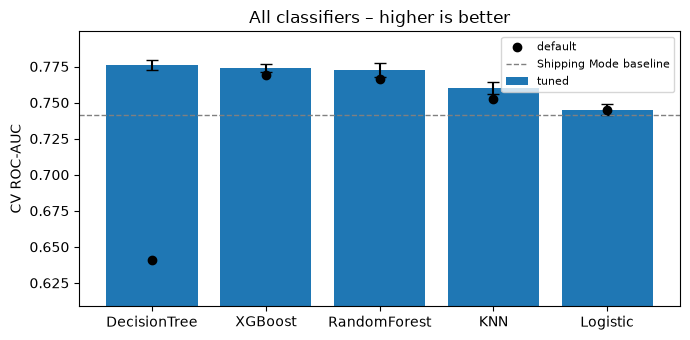

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(board.index, board["roc_auc"], yerr=board["roc_auc_std"], capsize=4, label="tuned")
ax.scatter(board.index, board["default_roc_auc"], color="black", zorder=3, label="default")
ax.axhline(MODE_BASELINE_AUC, color="grey", ls="--", lw=1, label="Shipping Mode baseline")
ax.set_ylabel("CV ROC-AUC"); ax.set_title("All classifiers – higher is better")
ax.set_ylim(min(board["default_roc_auc"].min(), MODE_BASELINE_AUC) * 0.95, min(1, board["roc_auc"].max() * 1.03))
ax.legend(fontsize=8)
show(fig, "01_model_comparison")

## Step 3 – Choose the final classifier
Highest ROC-AUC wins; any model within its fold noise counts as a tie, and a tie goes to the **simpler** model
(Logistic → Decision Tree → KNN → Random Forest → XGBoost).

In [4]:
SIMPLICITY = ["Logistic", "DecisionTree", "KNN", "RandomForest", "XGBoost"]
best_name = board.index[0]
threshold_zone = board.loc[best_name, "roc_auc"] - board.loc[best_name, "roc_auc_std"]
tied = board[board["roc_auc"] >= threshold_zone].index.tolist()
WINNER = min(tied, key=SIMPLICITY.index)
print(f"Highest ROC-AUC: {best_name} ({board.loc[best_name, 'roc_auc']:.4f} ± {board.loc[best_name, 'roc_auc_std']:.4f})")
print(f"Tie zone (ROC-AUC >= {threshold_zone:.4f}): {tied}")
print(f"FINAL CLASSIFIER: {WINNER}")
print("Beats the Shipping Mode baseline:", bool(board.loc[WINNER, "beats_baseline"]))

Highest ROC-AUC: DecisionTree (0.7761 ± 0.0033)
Tie zone (ROC-AUC >= 0.7728): ['DecisionTree', 'XGBoost']
FINAL CLASSIFIER: DecisionTree
Beats the Shipping Mode baseline: True


## Step 4 – Rebuild the final classifier

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

def make_model(name):
    if name == "Logistic":
        return LogisticRegression(max_iter=2000)
    if name == "RandomForest":
        return RandomForestClassifier(max_samples=0.5, n_jobs=-1, random_state=SEED)
    if name == "XGBoost":
        from xgboost import XGBClassifier
        return XGBClassifier(tree_method="hist", eval_metric="logloss", n_jobs=-1, random_state=SEED)
    if name == "DecisionTree":
        return DecisionTreeClassifier(random_state=SEED)
    if name == "KNN":
        return KNeighborsClassifier(n_jobs=-1)
    raise ValueError(name)

info = params[WINNER]
final_pipe = build_full_pipeline(make_model(WINNER).set_params(**info["best_params"]), PLAN, info["scaler"])
mode_plan = {"numeric": [], "onehot": ["Shipping Mode"], "onehot_rare": [], "target": []}
baseline_pipe = build_full_pipeline(LogisticRegression(max_iter=1000), mode_plan, "standard")

train = pd.read_csv(PROCESSED_DIR / "train_clf_fe.csv")
test = pd.read_csv(PROCESSED_DIR / "test_clf_fe.csv")
if CATEGORY_COL == "Category Id":
    train[CATEGORY_COL] = train[CATEGORY_COL].astype(str)
    test[CATEGORY_COL] = test[CATEGORY_COL].astype(str)
X, y, groups = train[FEATURES + [GROUP]], train[TARGET], train[GROUP]
print(f"Rebuilt {WINNER} with {info['best_params']}")

Rebuilt DecisionTree with {'min_samples_split': 10, 'min_samples_leaf': 20, 'max_depth': 5, 'class_weight': 'balanced'}


## Step 5 – Choose the alarm level (threshold)
The model gives a **probability** of being late. The **threshold** decides when we raise the alarm "late":
- a **low** threshold catches more late orders (higher **recall**) but raises more false alarms (lower precision);
- a **high** threshold raises fewer false alarms but misses more late orders.

The threshold is chosen on **out-of-fold predictions from the training set** (never the test set): the one with the best balance of
**late orders caught (recall) minus false alarm rate** (Youden's J). We do not simply maximise F1, because when most orders are late,
F1 can be maximised by flagging almost everything – which is useless.

In [6]:
cv_splits = make_cv(X, y, groups)
_, _, oof = cv_evaluate(final_pipe, X, y, cv_splits, return_proba=True)
rows = []
for t in np.arange(0.2, 0.81, 0.05):
    pred = (oof >= t).astype(int)
    recall = recall_score(y, pred, zero_division=0)
    false_alarm = ((pred == 1) & (y.to_numpy() == 0)).sum() / max((y == 0).sum(), 1)
    rows.append({"threshold": round(t, 2), "precision": precision_score(y, pred, zero_division=0), "recall": recall,
                 "false_alarm_rate": false_alarm, "f1": f1_score(y, pred, zero_division=0),
                 "youden_J": recall - false_alarm, "flagged_%": pred.mean() * 100})
thr_table = pd.DataFrame(rows)
THRESHOLD = float(thr_table.loc[thr_table["youden_J"].idxmax(), "threshold"])
print(f"Chosen threshold (best recall minus false-alarm rate on training folds): {THRESHOLD}")
thr_table.round(3)

Chosen threshold (best recall minus false-alarm rate on training folds): 0.65


,threshold,precision,recall,false_alarm_rate,f1,youden_J,flagged_%
0,0.20,0.588,0.999,0.934,0.741,0.065,97.114
1,0.25,0.589,0.997,0.930,0.740,0.067,96.851
2,0.30,0.595,0.979,0.892,0.740,0.087,94.195
3,0.35,0.831,0.623,0.169,0.712,0.454,42.867
4,0.40,0.884,0.590,0.104,0.707,0.486,38.156
5,0.45,0.890,0.587,0.097,0.707,0.490,37.725
6,0.50,0.894,0.585,0.093,0.707,0.492,37.416
7,0.55,0.894,0.585,0.093,0.707,0.492,37.416
8,0.60,0.894,0.585,0.093,0.707,0.492,37.399
9,0.65,0.894,0.584,0.093,0.707,0.492,37.389


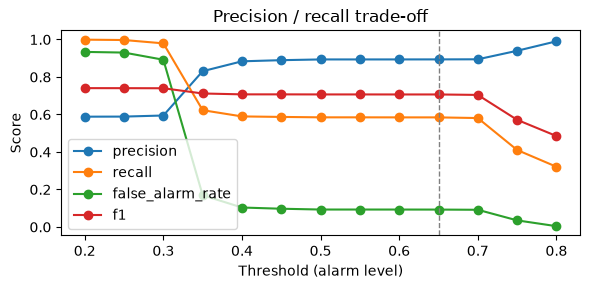

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
for m in ["precision", "recall", "false_alarm_rate", "f1"]:
    ax.plot(thr_table["threshold"], thr_table[m], marker="o", label=m)
ax.axvline(THRESHOLD, color="grey", ls="--", lw=1)
ax.set_xlabel("Threshold (alarm level)"); ax.set_ylabel("Score"); ax.set_title("Precision / recall trade-off"); ax.legend()
show(fig, "02_threshold_tradeoff")

## Step 6 – The final test (only once)
The final classifier is trained on the whole training set and tested **once** on the hidden test set – with the usual 0.5 cut-off and with
the chosen threshold. The baseline is tested the same way for comparison.

In [8]:
X_tr, X_te, y_te = train[FEATURES], test[FEATURES], test[TARGET]
final_pipe.fit(X_tr, y)
baseline_pipe.fit(X_tr, y)
proba_te = final_pipe.predict_proba(X_te)[:, 1]
base_proba = baseline_pipe.predict_proba(X_te)[:, 1]
test_scores = classification_metrics(y_te, (proba_te >= THRESHOLD).astype(int), proba_te)
final_table = pd.DataFrame({
    f"{WINNER} – CV (0.5)": info["cv_scores_tuned"],
    f"{WINNER} – TEST (0.5)": classification_metrics(y_te, (proba_te >= 0.5).astype(int), proba_te),
    f"{WINNER} – TEST (threshold {THRESHOLD})": test_scores,
    "Shipping Mode baseline – TEST (0.5)": classification_metrics(y_te, (base_proba >= 0.5).astype(int), base_proba),
}).loc[METRICS]
print(f"Test set: {len(X_te):,} rows, {test[GROUP].nunique():,} orders, late {y_te.mean() * 100:.1f}%")
final_table.round(4)

Test set: 34,534 rows, 12,579 orders, late 57.7%


,DecisionTree – CV (0.5),DecisionTree – TEST (0.5),DecisionTree – TEST (threshold 0.65),Shipping Mode baseline – TEST (0.5)
roc_auc,0.7761,0.7732,0.7732,0.7432
accuracy,0.7228,0.7237,0.7237,0.6993
precision,0.8937,0.8939,0.8939,0.8879
recall,0.5847,0.5917,0.5917,0.5485
f1,0.7069,0.7120,0.7120,0.6781


## Step 7 – Understand the results
### 7.1 Confusion matrix (test set, chosen threshold)

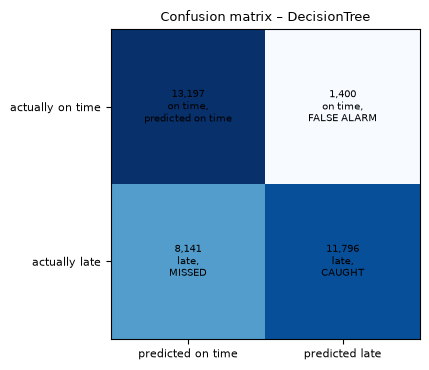

In [9]:
pred_te = (proba_te >= THRESHOLD).astype(int)
cm = confusion_matrix(y_te, pred_te, labels=[0, 1])
cell_text = [["on time,\npredicted on time", "on time,\nFALSE ALARM"], ["late,\nMISSED", "late,\nCAUGHT"]]
fig, ax = plt.subplots(figsize=(4.5, 3.8))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}\n{cell_text[i][j]}", ha="center", va="center", fontsize=7)
ax.set_xticks([0, 1]); ax.set_xticklabels(["predicted on time", "predicted late"], fontsize=8)
ax.set_yticks([0, 1]); ax.set_yticklabels(["actually on time", "actually late"], fontsize=8)
ax.set_title(f"Confusion matrix – {WINNER}", fontsize=9)
show(fig, "03_confusion_matrix")

### 7.2 ROC curve
The further the curve bows towards the top-left corner, the better the model separates late from on-time orders (the diagonal = random guessing).

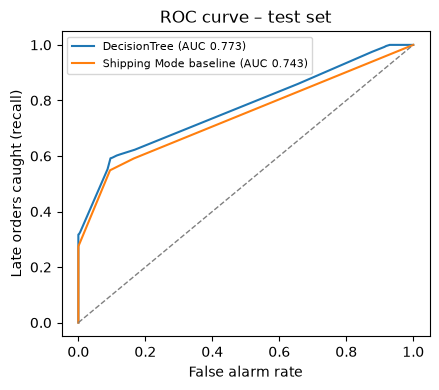

In [10]:
fig, ax = plt.subplots(figsize=(4.5, 4))
for name, p in [(WINNER, proba_te), ("Shipping Mode baseline", base_proba)]:
    fpr, tpr, _ = roc_curve(y_te, p)
    ax.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_te, p):.3f})")
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
ax.set_xlabel("False alarm rate"); ax.set_ylabel("Late orders caught (recall)"); ax.set_title("ROC curve – test set"); ax.legend(fontsize=8)
show(fig, "04_roc_curve")

### 7.3 Late rate and catch rate by shipping mode

In [11]:
pd.DataFrame({"mode": test["Shipping Mode"], "late": y_te, "pred": pred_te}).groupby("mode").agg(
    orders=("late", "size"), actual_late_pct=("late", lambda s: s.mean() * 100), flagged_pct=("pred", lambda s: s.mean() * 100)).round(1)

,orders,actual_late_pct,flagged_pct
mode,,,
First Class,5470,100.0,100.0
Same Day,1878,45.0,45.0
Second Class,6846,79.8,100.0
Standard Class,20340,40.1,0.2


## Step 8 – What drives late-delivery risk
Each feature is shuffled in turn; the more the ROC-AUC drops, the more the model relies on it.

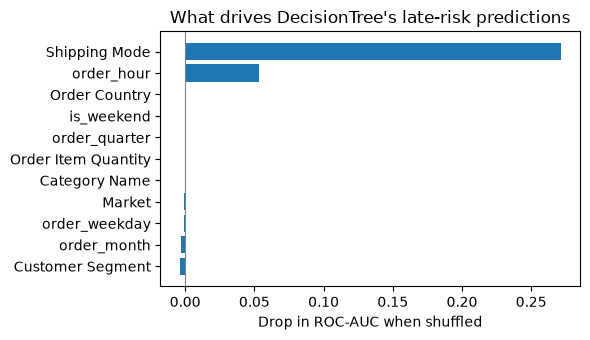

,ROC-AUC drop
Shipping Mode,0.2715
order_hour,0.0534
Order Country,0.0005
Category Name,0.0000
Order Item Quantity,0.0000
order_quarter,0.0000
is_weekend,0.0000
Market,-0.0007
order_weekday,-0.0007
order_month,-0.0032


In [12]:
sample = X_te.sample(min(20000, len(X_te)), random_state=SEED)
perm = permutation_importance(final_pipe, sample, y_te.loc[sample.index], n_repeats=3, random_state=SEED, scoring="roc_auc")
importance = pd.Series(perm.importances_mean, index=FEATURES, name="ROC-AUC drop").sort_values()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(importance.index, importance.values); ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Drop in ROC-AUC when shuffled"); ax.set_title(f"What drives {WINNER}'s late-risk predictions")
show(fig, "05_feature_importance")
importance.sort_values(ascending=False).round(4).to_frame()

## Step 9 – Save the final classifier for the backend
`models/clf_final_pipeline.pkl` is the complete pipeline (encoding + scaling + model). `models/clf_model_info.json` holds the features,
the chosen **threshold**, how to make the date features, the allowed dropdown values and the scores.

In [13]:
import sklearn
joblib.dump(final_pipe, MODELS_DIR / "clf_final_pipeline.pkl")
date_features = m3.get("date_features", [])
categorical = [f for f in FEATURES if not pd.api.types.is_numeric_dtype(X_tr[f])]
model_info = {"task": "classification", "target": TARGET, "model": WINNER, "best_params": info["best_params"],
              "scaler": info["scaler"], "threshold": THRESHOLD, "features": FEATURES,
              "input_fields": [f for f in FEATURES if f not in date_features] + [DATE_COL],
              "date_column": DATE_COL, "date_format": DATE_FMT, "date_features": date_features,
              "not_used": m3.get("not_used", []),
              "allowed_values": {f: sorted(X_tr[f].astype(str).unique().tolist()) for f in categorical},
              "quantity_range": [int(X_tr["Order Item Quantity"].min()), int(X_tr["Order Item Quantity"].max())],
              "cv_scores": info["cv_scores_tuned"], "test_scores": {k: round(float(v), 4) for k, v in test_scores.items()},
              "versions": {"scikit-learn": sklearn.__version__, "pandas": pd.__version__}}
(MODELS_DIR / "clf_model_info.json").write_text(json.dumps(model_info, indent=2, ensure_ascii=False), encoding="utf-8")
log_experiment({"owner": "Team", "experiment": "FINAL_test", "model": WINNER, "n_features": len(FEATURES),
                **{m: test_scores[m] for m in METRICS}, "roc_auc_std": None})
reloaded = joblib.load(MODELS_DIR / "clf_final_pipeline.pkl")
print("Saved clf_final_pipeline.pkl and clf_model_info.json | reload check:",
      np.allclose(reloaded.predict_proba(X_te.head(100))[:, 1], proba_te[:100]))

Saved clf_final_pipeline.pkl and clf_model_info.json | reload check: True


/var/folders/z6/_ps_74r15fvbsdpf70xphk5m0000gn/T/ipykernel_89916/3673454984.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new


## Step 10 – Final summary

In [14]:
top = importance.sort_values(ascending=False)
print(f"""
FINAL CLASSIFIER {WINNER} (owner {info['owner']}) with {info['best_params']}
CV ROC-AUC       {info['cv_scores_tuned']['roc_auc']:.4f} ± {info['cv_roc_auc_std']:.4f} | beats baseline: {bool(board.loc[WINNER, 'beats_baseline'])}
THRESHOLD        {THRESHOLD} (best recall minus false-alarm rate, training folds)
TEST             ROC-AUC {test_scores['roc_auc']:.3f} | accuracy {test_scores['accuracy']:.3f} | precision {test_scores['precision']:.3f} | recall {test_scores['recall']:.3f} | F1 {test_scores['f1']:.3f}
TOP DRIVERS      {", ".join(top.index[:3])}
SAVED            models/clf_final_pipeline.pkl, models/clf_model_info.json
""")


FINAL CLASSIFIER DecisionTree (owner M4) with {'min_samples_split': 10, 'min_samples_leaf': 20, 'max_depth': 5, 'class_weight': 'balanced'}
CV ROC-AUC       0.7761 ± 0.0033 | beats baseline: True
THRESHOLD        0.65 (best recall minus false-alarm rate, training folds)
TEST             ROC-AUC 0.773 | accuracy 0.724 | precision 0.894 | recall 0.592 | F1 0.712
TOP DRIVERS      Shipping Mode, order_hour, Order Country
SAVED            models/clf_final_pipeline.pkl, models/clf_model_info.json



**In plain words for the presentation:** "On orders it had never seen, the model catches *[recall]* of the late orders; when it raises an
alarm, it is right *[precision]* of the time. Shipping mode is the biggest driver of late delivery."